In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("zomato.csv")
print(df.shape)       # how many rows and columns
print(df.head())      # first 5 rows

(51717, 17)
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1          Yes        

In [15]:
# Clean the 'rate' column (it looks like "4.1/5" — we need just 4.1)
df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean cost column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',','')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

# Rename for convenience
df.rename(columns={'approx_cost(for two people)': 'cost'}, inplace=True)

print(df[['rate','cost','online_order']].describe())

               rate          cost
count  41665.000000  51371.000000
mean       3.700449    555.431566
std        0.440513    438.850728
min        1.800000     40.000000
25%        3.400000    300.000000
50%        3.700000    400.000000
75%        4.000000    650.000000
max        4.900000   6000.000000


online_order
No     3.66
Yes    3.72
Name: rate, dtype: float64


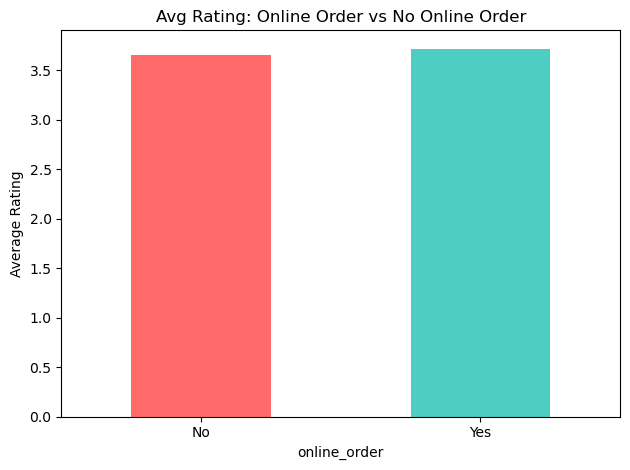

In [16]:
online_rating = df.groupby('online_order')['rate'].mean().round(2)
print(online_rating)

online_rating.plot(kind='bar', color=['#FF6B6B','#4ECDC4'], 
                   title='Avg Rating: Online Order vs No Online Order')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('online_vs_rating.png')
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_8304\2802810915.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_rating = df.groupby('price_range')['rate'].mean().round(2)


price_range
Budget(0-300)        3.57
Mid(300-600)         3.62
Premium(600-1000)    3.80
Luxury(1000+)        4.13
Name: rate, dtype: float64


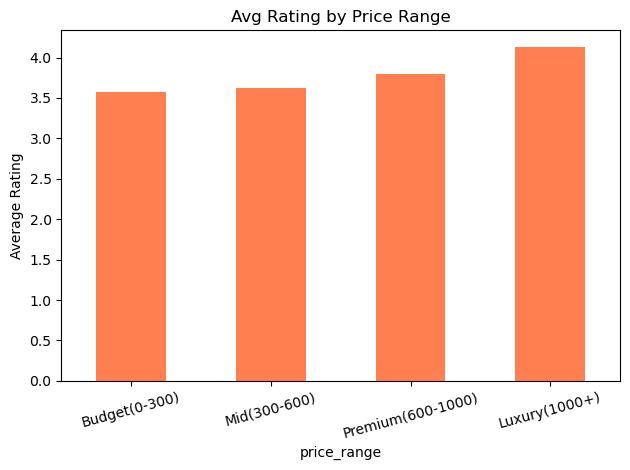

In [20]:
df['price_range'] = pd.cut(df['cost'], 
                            bins=[0,300,600,1000,5000],
                            labels=['Budget(0-300)',
                                    'Mid(300-600)',
                                    'Premium(600-1000)',
                                    'Luxury(1000+)'])

price_rating = df.groupby('price_range')['rate'].mean().round(2)
print(price_rating)

price_rating.plot(kind='bar', color='coral',
                  title='Avg Rating by Price Range')
plt.ylabel('Average Rating')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('price_vs_rating.png')
plt.show()

In [22]:
cuisine_analysis = df.groupby('cuisines').agg(
    avg_rating=('rate','mean'),
    avg_cost=('cost','mean'),
    count=('name','count')
).round(2)

# Filter cuisines with enough data
cuisine_analysis = cuisine_analysis[cuisine_analysis['count'] > 50]

# Find overpriced (high cost, low rating)
overpriced = cuisine_analysis[
    (cuisine_analysis['avg_cost'] > cuisine_analysis['avg_cost'].mean()) &
    (cuisine_analysis['avg_rating'] < cuisine_analysis['avg_rating'].mean())
].sort_values('avg_cost', ascending=False).head(5)

print("Overpriced Cuisines:\n", overpriced)

Overpriced Cuisines:
                                     avg_rating  avg_cost  count
cuisines                                                       
North Indian, Continental, Chinese        3.35   1289.69     97
Continental                               3.66   1020.26    196
North Indian, Chinese, Continental        3.61    892.06    126
North Indian, Mughlai, Biryani            3.59    801.12     89
North Indian, Chinese, Mughlai            3.55    723.42     81


High Competition, Low Satisfaction Areas:
                     avg_rating  total_restaurants
location                                         
Bommanahalli              3.19                238
Kumaraswamy Layout        3.46                195
Ejipura                   3.48                439
Electronic City           3.49               1258
Hennur                    3.49                161
Yeshwantpur               3.50                119
Majestic                  3.50                155
Shivajinagar              3.50                499
Nagawara                  3.50                187
South Bangalore           3.50                107


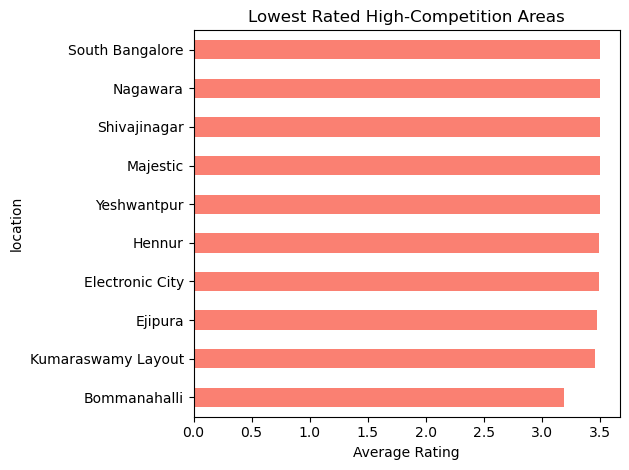

In [24]:
location_analysis = df.groupby('location').agg(
    avg_rating=('rate','mean'),
    total_restaurants=('name','count')
).round(2)

# High competition but low satisfaction areas
gap_areas = location_analysis[
    location_analysis['total_restaurants'] > 100
].sort_values('avg_rating').head(10)

print("High Competition, Low Satisfaction Areas:\n", gap_areas)

gap_areas['avg_rating'].plot(kind='barh', color='salmon',
                              title='Lowest Rated High-Competition Areas')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.savefig('market_gap.png')
plt.show()

In [29]:
# Install pandasql - this lets you run SQL inside Jupyter
!pip install pandasql


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26801 sha256=ad2439417d611c9f3a53a416b27ea8fd0297e0cace20c35d88d2926529d629c9
  Stored in directory: c:\users\acer\appdata\local\pip\cache\wheels\15\a1\e7\6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [30]:
from pandasql import sqldf
import pandas as pd

# Load your data
df = pd.read_csv("zomato.csv", encoding='latin-1')

# Clean column names first
df.columns = df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('(','').str.replace(')','')

print(df.columns.tolist())  # shows all column names

['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_costfor_two_people', 'reviews_list', 'menu_item', 'listed_intype', 'listed_incity']


In [38]:
# Find the cost column automatically
cost_col = [col for col in df.columns if 'cost' in col][0]
print("Cost column found:", cost_col)

# Clean rate column
df['rate'] = df['rate'].astype(str).str.split('/').str[0]
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean cost column dynamically
df[cost_col] = df[cost_col].astype(str).str.replace(',','')
df[cost_col] = pd.to_numeric(df[cost_col], errors='coerce')

# Rename it to 'cost' for easy use later
df.rename(columns={cost_col: 'cost'}, inplace=True)

print("Data cleaned! Shape:", df.shape)
print(df[['rate','cost']].head())

Cost column found: approx_costfor_two_people
Data cleaned! Shape: (51717, 17)
   rate   cost
0   4.1  800.0
1   4.1  800.0
2   3.8  800.0
3   3.7  300.0
4   3.8  600.0


In [40]:
pysqldf = lambda q: sqldf(q, globals())

q1 = pysqldf("""
    SELECT online_order, 
           ROUND(AVG(rate), 2) as avg_rating,
           COUNT(*) as total_restaurants
    FROM df
    GROUP BY online_order
""")
print(q1)

  online_order  avg_rating  total_restaurants
0           No        3.66              21273
1          Yes        3.72              30444


In [42]:
q2 = pysqldf("""
    SELECT rest_type,
           ROUND(AVG(rate), 2) as avg_rating,
           SUM(votes) as total_votes,
           COUNT(*) as count
    FROM df
    GROUP BY rest_type
    HAVING count > 50
    ORDER BY avg_rating DESC
    LIMIT 10
""")
print(q2)

                     rest_type  avg_rating  total_votes  count
0            Pub, Microbrewery        4.45       350648     84
1  Microbrewery, Casual Dining        4.37       157667    132
2  Casual Dining, Microbrewery        4.31       149107     59
3          Casual Dining, Cafe        4.19       528752    319
4           Casual Dining, Pub        4.18       180139    127
5                  Fine Dining        4.15       168073    346
6         Cafe, Dessert Parlor        4.15        54745    148
7         Dessert Parlor, Cafe        4.14       137709    175
8           Bar, Casual Dining        4.13       454532    425
9           Pub, Casual Dining        4.09       234751    255


In [44]:
q3 = pysqldf("""
    SELECT name, location, cost, rate, votes
    FROM df
    WHERE cost < 300 
    AND rate > 4.0 
    AND votes > 100
    ORDER BY rate DESC
    LIMIT 10
""")
print(q3)

                   name      location   cost  rate  votes
0  Brahmin's Coffee Bar  Basavanagudi  100.0   4.8   2679
1    O.G. Variar & Sons   Rajajinagar  200.0   4.8   1156
2                   CTR  Malleshwaram  150.0   4.8   4421
3    O.G. Variar & Sons   Rajajinagar  200.0   4.8   1161
4                   CTR  Malleshwaram  150.0   4.8   4421
5          Taaza Thindi  Banashankari  100.0   4.7    651
6                   CTR  Malleshwaram  150.0   4.7   4408
7                   CTR  Malleshwaram  150.0   4.7   4408
8      Apsara Ice Cream   Indiranagar  200.0   4.6    206
9     Natural Ice Cream   Indiranagar  150.0   4.6    922


In [46]:
q4 = pysqldf("""
    SELECT location,
           ROUND(AVG(rate), 2) as avg_rating,
           COUNT(*) as total_restaurants
    FROM df
    GROUP BY location
    HAVING total_restaurants > 100
    ORDER BY avg_rating ASC
    LIMIT 10
""")
print(q4)

             location  avg_rating  total_restaurants
0        Bommanahalli        3.19                238
1  Kumaraswamy Layout        3.46                195
2             Ejipura        3.48                439
3     Electronic City        3.49               1258
4              Hennur        3.49                161
5           Banaswadi        3.50                664
6            Majestic        3.50                155
7            Nagawara        3.50                187
8        Shivajinagar        3.50                499
9     South Bangalore        3.50                107


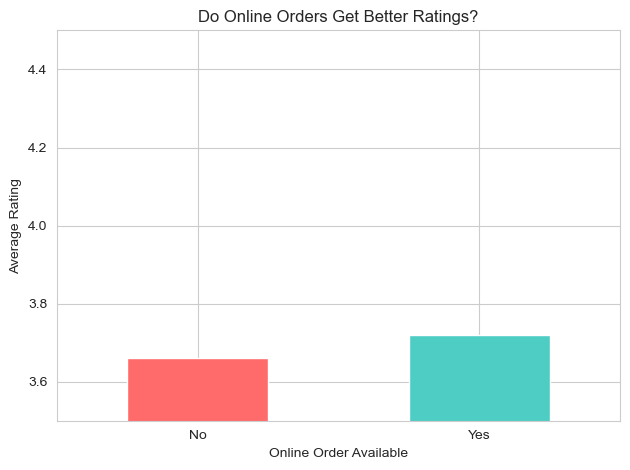

Chart 1 saved!


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

q1.plot(kind='bar', x='online_order', y='avg_rating', 
        color=['#FF6B6B','#4ECDC4'],
        title='Do Online Orders Get Better Ratings?',
        legend=False)
plt.ylabel('Average Rating')
plt.xlabel('Online Order Available')
plt.xticks(rotation=0)
plt.ylim(3.5, 4.5)
plt.tight_layout()
plt.savefig('chart1_online_vs_rating.png', dpi=150)
plt.show()
print("Chart 1 saved!")

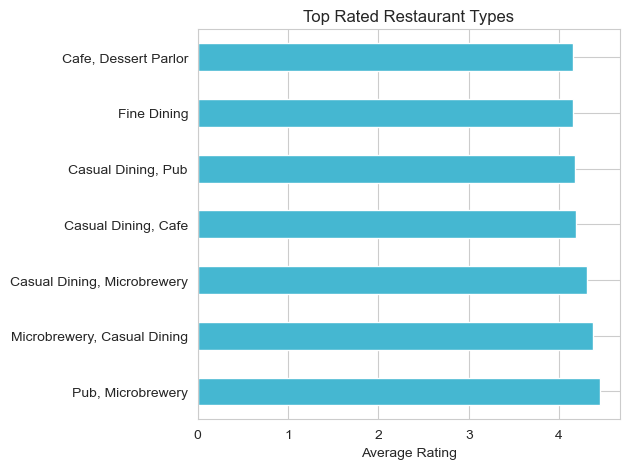

Chart 2 saved!


In [50]:
q2_top = q2.head(7)
q2_top.plot(kind='barh', x='rest_type', y='avg_rating',
            color='#45B7D1',
            title='Top Rated Restaurant Types',
            legend=False)
plt.xlabel('Average Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart2_rest_type.png', dpi=150)
plt.show()
print("Chart 2 saved!")

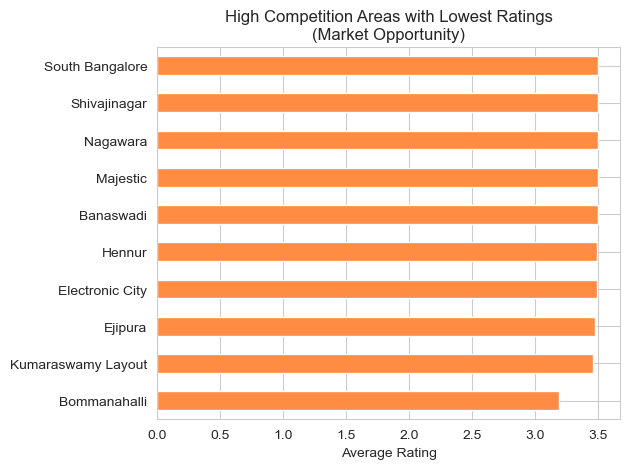

Chart 3 saved!


In [52]:
q4.plot(kind='barh', x='location', y='avg_rating',
        color='#FF8C42',
        title='High Competition Areas with Lowest Ratings\n(Market Opportunity)',
        legend=False)
plt.xlabel('Average Rating')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart3_market_gap.png', dpi=150)
plt.show()
print("Chart 3 saved!")

C:\Users\Acer\AppData\Local\Temp\ipykernel_8304\126178815.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_rating = df.groupby('price_range')['rate'].mean().round(2)


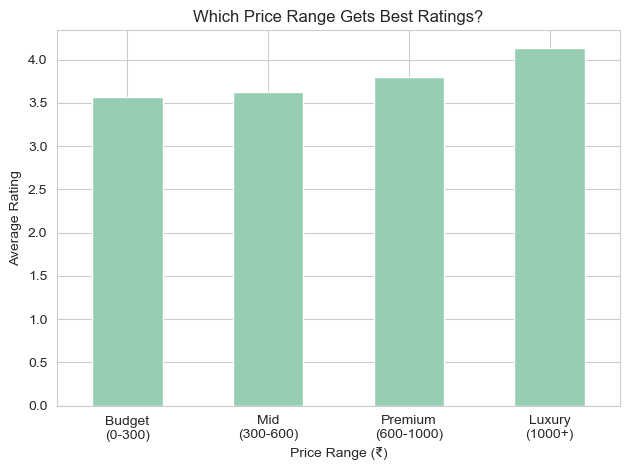

Chart 4 saved!


In [54]:
df['price_range'] = pd.cut(df['cost'],
                            bins=[0,300,600,1000,5000],
                            labels=['Budget\n(0-300)',
                                    'Mid\n(300-600)',
                                    'Premium\n(600-1000)',
                                    'Luxury\n(1000+)'])

price_rating = df.groupby('price_range')['rate'].mean().round(2)

price_rating.plot(kind='bar', color='#96CEB4',
                  title='Which Price Range Gets Best Ratings?',
                  legend=False)
plt.ylabel('Average Rating')
plt.xlabel('Price Range (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart4_price_vs_rating.png', dpi=150)
plt.show()
print("Chart 4 saved!")